# fio-cmp: DAOS (dfs) vs NSF

Sequential read comparison across block sizes 4K / 1M / 4M.
Single job, iodepth=32. Metrics: bandwidth, IOPS, latency percentiles, CPU usage.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

RESULTS_DIR = Path(".")

BS_ORDER = ["4k", "1m", "4m"]
COLORS   = {"daos": "#1f77b4", "nsf": "#ff7f0e"}


## Multi-Run Variability — CV%

DAOS-DFS, NFS-libaio, NFS-pvsync2; sequential read, nj=1, iodepth=32.  
CV% = (std / mean) × 100 across repeated runs per block size.

In [2]:
import statistics
from IPython.display import display

def _load_fio(pattern):
    """Load fio JSON files; return DataFrame with per-run BW, lat, CPU metrics."""
    files = sorted(RESULTS_DIR.glob(pattern))
    records = []
    for fpath in files:
        with open(fpath) as f:
            d = json.load(f)
        j = d["jobs"][0]
        r = j["read"]
        records.append(dict(
            file        = fpath.name,
            bw_GiBs     = r["bw_bytes"] / (1024**3),
            iops        = r["iops"],
            lat_mean_ms = r["lat_ns"]["mean"] / 1e6,
            usr_cpu     = j["usr_cpu"],
            sys_cpu     = j["sys_cpu"],
        ))
    return pd.DataFrame(records)

_CV_CONFIGS = {
    ("DAOS-DFS",    "4k"): "dfs_seq_read_bs4k_*.json",
    ("DAOS-DFS",    "1m"): "dfs_seq_read_bs1m_*.json",
    ("DAOS-DFS",    "4m"): "dfs_seq_read_bs4m_*.json",
    ("NFS-libaio",  "4k"): "libaio_nsf_seq_read_bs4k_*.json",
    ("NFS-libaio",  "1m"): "libaio_nsf_seq_read_bs1m_*.json",
    ("NFS-libaio",  "4m"): "libaio_nsf_seq_read_bs4m_*.json",
    ("NFS-pvsync2", "4k"): "pvsync2_nsf_seq_read_bs4k_*.json",
    ("NFS-pvsync2", "1m"): "pvsync2_nsf_seq_read_bs1m_*.json",
    ("NFS-pvsync2", "4m"): "pvsync2_nsf_seq_read_bs4m_*.json",
}

_run_data = {key: _load_fio(pat) for key, pat in _CV_CONFIGS.items()}

cv_rows = []
for (system, bs), df in _run_data.items():
    for metric, label in [("bw_GiBs", "BW (GiB/s)"), ("lat_mean_ms", "Lat (ms)")]:
        vals = df[metric].tolist()
        mu = statistics.mean(vals)
        sd = statistics.stdev(vals) if len(vals) > 1 else 0.0
        cv_rows.append(dict(System=system, bs=bs, Metric=label, N=len(vals),
                            Mean=round(mu, 4), Std=round(sd, 4), CV_pct=round(sd / mu * 100, 2)))

cv_df = pd.DataFrame(cv_rows)
pivot = cv_df.pivot_table(index=["System", "bs"], columns="Metric", values="CV_pct")
pivot.columns.name = None
pivot = pivot[["BW (GiB/s)", "Lat (ms)"]].rename(columns={"BW (GiB/s)": "BW CV%", "Lat (ms)": "Lat CV%"})

pd.set_option("display.float_format", "{:.2f}".format)
print("Multi-run CV%  (DAOS-DFS / NFS-libaio / NFS-pvsync2)\n")
display(pivot)

Multi-run CV%  (DAOS-DFS / NFS-libaio / NFS-pvsync2)



BW CV%  Lat CV%
System      bs                 
DAOS-DFS    1m   45.62    73.52
            4k    3.70     3.80
            4m   44.25    70.52
NFS-libaio  1m    4.23     4.99
            4k    7.00     7.91
            4m    4.21     5.31
NFS-pvsync2 1m    4.27     5.15
            4k    8.35     8.65
            4m    3.68     1.03

## Multi-Run Performance: Median BW, Mean Latency & CPU Usage

DAOS-DFS vs NFS-libaio vs NFS-pvsync2; sequential read, nj=1, iodepth=32.  
BW bars show **median** across repeated runs; latency bars show mean of per-run mean latency;  
CPU shows mean usr (solid) + sys (hatched) across runs.

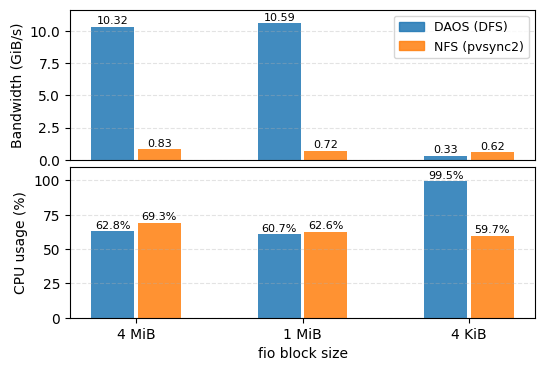

In [3]:
from matplotlib.patches import Patch

_SYSTEMS   = ["DAOS-DFS", "NFS-pvsync2"]
_DISPLAY   = ["DAOS (DFS)", "NFS (pvsync2)"]
_BS_ORDER  = ["4m", "1m", "4k"]
_BS_LABELS = ["4 MiB", "1 MiB", "4 KiB"]

tab10  = plt.colormaps["tab10"]
colors = [tab10(0), tab10(1)]

width   = 0.28
x       = np.arange(len(_BS_ORDER))
offsets = np.array([-0.5, 0.5]) * width

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
fig.subplots_adjust(hspace=0.05)

for i, (sys_, dname, color) in enumerate(zip(_SYSTEMS, _DISPLAY, colors)):
    bw_vals  = [np.median(_run_data[(sys_, bs)]["bw_GiBs"]) for bs in _BS_ORDER]
    usr_vals = [_run_data[(sys_, bs)]["usr_cpu"].mean()     for bs in _BS_ORDER]
    sys_vals = [_run_data[(sys_, bs)]["sys_cpu"].mean()     for bs in _BS_ORDER]
    cpu_vals = [u + s for u, s in zip(usr_vals, sys_vals)]

    bars_bw = ax_top.bar(x + offsets[i], bw_vals, width * 0.92, color=color, alpha=0.85, label=dname)
    for bar, v in zip(bars_bw, bw_vals):
        ax_top.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    bars_cpu = ax_bot.bar(x + offsets[i], cpu_vals, width * 0.92, color=color, alpha=0.85)
    for bar, v in zip(bars_cpu, cpu_vals):
        ax_bot.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

bw_max  = max(np.median(_run_data[(s, bs)]["bw_GiBs"]) for s in _SYSTEMS for bs in _BS_ORDER)
cpu_max = max(
    (_run_data[(s, bs)]["usr_cpu"] + _run_data[(s, bs)]["sys_cpu"]).mean()
    for s in _SYSTEMS for bs in _BS_ORDER
)

ax_top.set_ylim(0, bw_max * 1.1)
ax_top.set_ylabel("Bandwidth (GiB/s)", fontsize=10)
ax_top.grid(axis="y", linestyle="--", alpha=0.35)
ax_top.tick_params(bottom=False)

# Single shared legend at the top
ax_top.legend(
    handles=[Patch(color=colors[i], alpha=0.85, label=_DISPLAY[i]) for i in range(len(_SYSTEMS))],
    fontsize=9, loc="best"
)

ax_bot.set_ylim(0, cpu_max * 1.1)
ax_bot.set_ylabel("CPU usage (%)", fontsize=10)
ax_bot.grid(axis="y", linestyle="--", alpha=0.35)
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(_BS_LABELS, fontsize=10)
ax_bot.set_xlabel("fio block size", fontsize=10)



plt.savefig("fio-cmp_dfs-pvsync2_bw-cpu.pdf", dpi=150, bbox_inches="tight")
plt.show()


## Network File System (NFS) Result Analysis


### pvsync2 engine, bs = 4m

10 repeated runs of `pvsync2` ioengine on NSF (seq read, bs=4M, nj=1, iodepth=32) to assess run-to-run variance.

In [4]:
import statistics

def load_nsf(pattern):
    """Load NSF fio JSON files matching glob pattern; return (per-run df, summary df)."""
    files = sorted(RESULTS_DIR.glob(pattern))
    records = []
    for fpath in files:
        with open(fpath) as f:
            d = json.load(f)
        r = d["jobs"][0]["read"]
        records.append(dict(
            file        = fpath.name,
            bw_GiBs     = r["bw_bytes"] / (1024**3),
            iops        = r["iops"],
            lat_mean_ms = r["lat_ns"]["mean"] / 1e6,
            clat_p50_ms = r["clat_ns"]["percentile"]["50.000000"] / 1e6,
        ))
    df = pd.DataFrame(records)
    summary = {}
    for col in ["bw_GiBs", "iops", "lat_mean_ms", "clat_p50_ms"]:
        vals = df[col].tolist()
        mu  = statistics.mean(vals)
        sd  = statistics.stdev(vals) if len(vals) > 1 else 0.0
        summary[col] = dict(min=min(vals), max=max(vals), mean=mu, std=sd, cv_pct=sd/mu*100)
    summary_df = pd.DataFrame(summary).T.round(4)
    summary_df.index.name = "metric"
    return df, summary_df

pv2_4m_df, pv2_4m_summary = load_nsf("pvsync2_nsf_seq_read_bs4m_*.json")
print(f"pvsync2 / bs=4m  — {len(pv2_4m_df)} runs")
print(pv2_4m_df.to_string(index=False))
print()
print(pv2_4m_summary)

pvsync2 / bs=4m  — 10 runs
                                               file  bw_GiBs   iops  lat_mean_ms  clat_p50_ms
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810430.json     0.93 237.27         4.21         4.01
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810467.json     0.82 209.69         4.25         4.05
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810507.json     0.83 213.22         4.17         3.95
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810546.json     0.83 213.44         4.16         3.98
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810586.json     0.83 213.42         4.16         3.95
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810626.json     0.84 214.32         4.14         3.95
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810665.json     0.83 212.71         4.17         3.98
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810705.json     0.84 215.99         4.11         3.92
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810744.json     0.83 213.17         4.17         3.95
pvsync2_nsf_seq_read_bs4m_nj1_iod

---
### pvsync2 engine — bs = 4k

10 repeated runs of `pvsync2` ioengine on NFS (seq read, bs=4k, nj=1, iodepth=32).

In [5]:
pv2_4k_df, pv2_4k_summary = load_nsf("pvsync2_nsf_seq_read_bs4k_*.json")
print(f"pvsync2 / bs=4k  — {len(pv2_4k_df)} runs")
print(pv2_4k_df.to_string(index=False))
print()
print(pv2_4k_summary)

pvsync2 / bs=4k  — 10 runs
                                               file  bw_GiBs      iops  lat_mean_ms  clat_p50_ms
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159360.json     0.70 183085.44         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159406.json     0.62 162554.46         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159458.json     0.62 162469.80         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159509.json     0.62 163117.56         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159560.json     0.53 138950.99         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159620.json     0.62 163416.62         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159671.json     0.52 136295.05         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159731.json     0.62 162777.11         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159782.json     0.62 163709.63         0.01         0.00
pvs

---
### pvsync2 engine — bs = 1m

10 repeated runs of `pvsync2` ioengine on NFS (seq read, bs=1m, nj=1, iodepth=32).

In [6]:
pv2_1m_df, pv2_1m_summary = load_nsf("pvsync2_nsf_seq_read_bs1m_*.json")
print(f"pvsync2 / bs=1m  — {len(pv2_1m_df)} runs")
print(pv2_1m_df.to_string(index=False))
print()
print(pv2_1m_summary)

pvsync2 / bs=1m  — 10 runs
                                               file  bw_GiBs   iops  lat_mean_ms  clat_p50_ms
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161076.json     0.73 743.81         1.21         1.45
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161120.json     0.71 730.24         1.24         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161166.json     0.74 757.69         1.19         1.42
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161210.json     0.63 643.67         1.42         1.71
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161260.json     0.72 732.18         1.23         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161306.json     0.72 740.86         1.22         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161350.json     0.72 735.93         1.23         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161396.json     0.72 739.73         1.22         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161440.json     0.72 733.42         1.23         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod

---
### libaio engine — bs = 4k

10 repeated runs of `libaio` ioengine on NFS (seq read, bs=4k, nj=1, iodepth=32).

In [7]:
la_4k_df, la_4k_summary = load_nsf("libaio_nsf_seq_read_bs4k_*.json")
print(f"libaio / bs=4k  — {len(la_4k_df)} runs")
print(la_4k_df.to_string(index=False))
print()
print(la_4k_summary)

libaio / bs=4k  — 10 runs
                                              file  bw_GiBs      iops  lat_mean_ms  clat_p50_ms
libaio_nsf_seq_read_bs4k_nj1_iod32_1782159915.json     0.56 146401.05         0.20         0.10
libaio_nsf_seq_read_bs4k_nj1_iod32_1782159971.json     0.49 127154.24         0.23         0.15
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160035.json     0.49 127342.39         0.23         0.15
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160099.json     0.56 146673.51         0.20         0.10
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160156.json     0.56 145754.09         0.20         0.10
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160213.json     0.58 152204.59         0.19         0.09
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160267.json     0.56 147418.60         0.20         0.10
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160323.json     0.56 146163.83         0.20         0.10
libaio_nsf_seq_read_bs4k_nj1_iod32_1782160380.json     0.49 127333.73         0.23         0.15
libaio_nsf_seq

---
### libaio engine — bs = 1m

10 repeated runs of `libaio` ioengine on NFS (seq read, bs=1m, nj=1, iodepth=32).

In [8]:
la_1m_df, la_1m_summary = load_nsf("libaio_nsf_seq_read_bs1m_*.json")
print(f"libaio / bs=1m  — {len(la_1m_df)} runs")
print(la_1m_df.to_string(index=False))
print()
print(la_1m_summary)

libaio / bs=1m  — 10 runs
                                              file  bw_GiBs   iops  lat_mean_ms  clat_p50_ms
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161561.json     0.73 751.69        38.33        36.96
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161605.json     0.72 734.18        39.34        38.01
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161650.json     0.72 738.11        39.10        38.01
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161695.json     0.73 743.55        38.79        37.49
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161740.json     0.63 644.92        45.33        43.78
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161790.json     0.72 737.06        39.16        37.49
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161836.json     0.69 710.13        40.87        39.58
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161882.json     0.69 704.16        41.24        39.58
libaio_nsf_seq_read_bs1m_nj1_iod32_1782161929.json     0.70 717.80        40.37        39.58
libaio_nsf_seq_read_bs1m_nj1_iod32_178216197

---
### libaio engine — bs = 4m

13 runs of `libaio` ioengine on NFS (seq read, bs=4m, nj=1, iodepth=32).

In [9]:
la_4m_df, la_4m_summary = load_nsf("libaio_nsf_seq_read_bs4m_*.json")
print(f"libaio / bs=4m  — {len(la_4m_df)} runs")
print(la_4m_df.to_string(index=False))
print()
print(la_4m_summary)

libaio / bs=4m  — 13 runs
                                              file  bw_GiBs   iops  lat_mean_ms  clat_p50_ms
libaio_nsf_seq_read_bs4m_nj1_iod32_1781810824.json     0.80 204.81       139.14       133.69
libaio_nsf_seq_read_bs4m_nj1_iod32_1781810865.json     0.84 214.73       131.75       127.40
libaio_nsf_seq_read_bs4m_nj1_iod32_1781810904.json     0.85 218.01       129.71       126.35
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163291.json     0.71 181.36       159.36       154.14
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163337.json     0.83 212.91       132.82       128.45
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163377.json     0.83 211.61       134.24       130.55
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163417.json     0.81 208.52       136.43       131.60
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163457.json     0.82 209.57       135.73       130.55
libaio_nsf_seq_read_bs4m_nj1_iod32_1782163497.json     0.82 210.87       134.77       130.55
libaio_nsf_seq_read_bs4m_nj1_iod32_178216353

---
### psync engine — bs = 4k

10 repeated runs of `psync` ioengine on NFS (seq read, bs=4k, nj=1, iodepth=32).

In [10]:
ps_4k_df, ps_4k_summary = load_nsf("psync_nsf_seq_read_bs4k_*.json")
print(f"psync / bs=4k  — {len(ps_4k_df)} runs")
print(ps_4k_df.to_string(index=False))
print()
print(ps_4k_summary)

psync / bs=4k  — 10 runs
                                             file  bw_GiBs      iops  lat_mean_ms  clat_p50_ms
psync_nsf_seq_read_bs4k_nj1_iod32_1782160530.json     0.63 164975.78         0.01         0.00
psync_nsf_seq_read_bs4k_nj1_iod32_1782160581.json     0.63 164230.32         0.01         0.00
psync_nsf_seq_read_bs4k_nj1_iod32_1782160632.json     0.63 163985.72         0.01         0.00
psync_nsf_seq_read_bs4k_nj1_iod32_1782160683.json     0.52 136250.40         0.01         0.00
psync_nsf_seq_read_bs4k_nj1_iod32_1782160743.json     0.63 163992.90         0.01         0.00
psync_nsf_seq_read_bs4k_nj1_iod32_1782160794.json     0.64 168438.61         0.01         0.00
psync_nsf_seq_read_bs4k_nj1_iod32_1782160844.json     0.63 164306.00         0.01         0.00
psync_nsf_seq_read_bs4k_nj1_iod32_1782160895.json     0.65 169702.31         0.01         0.00
psync_nsf_seq_read_bs4k_nj1_iod32_1782160944.json     0.63 165041.24         0.01         0.00
psync_nsf_seq_read_bs4k_n

---
### psync engine — bs = 4m

10 repeated runs of `psync` ioengine on NFS (seq read, bs=4m, nj=1, iodepth=32).

In [11]:
ps_4m_df, ps_4m_summary = load_nsf("psync_nsf_seq_read_bs4m_*.json")
print(f"psync / bs=4m  — {len(ps_4m_df)} runs")
print(ps_4m_df.to_string(index=False))
print()
print(ps_4m_summary)

psync / bs=4m  — 10 runs
                                             file  bw_GiBs   iops  lat_mean_ms  clat_p50_ms
psync_nsf_seq_read_bs4m_nj1_iod32_1782163728.json     0.73 185.86         4.85         4.69
psync_nsf_seq_read_bs4m_nj1_iod32_1782163773.json     0.72 184.65         4.89         4.69
psync_nsf_seq_read_bs4m_nj1_iod32_1782163817.json     0.83 213.15         4.16         3.95
psync_nsf_seq_read_bs4m_nj1_iod32_1782163857.json     0.86 218.96         4.05         3.82
psync_nsf_seq_read_bs4m_nj1_iod32_1782163896.json     0.74 188.86         4.77         4.62
psync_nsf_seq_read_bs4m_nj1_iod32_1782163940.json     0.83 211.53         4.20         3.98
psync_nsf_seq_read_bs4m_nj1_iod32_1782163980.json     0.82 209.20         4.26         4.05
psync_nsf_seq_read_bs4m_nj1_iod32_1782164020.json     0.82 210.56         4.23         4.01
psync_nsf_seq_read_bs4m_nj1_iod32_1782164060.json     0.86 219.25         4.03         3.82
psync_nsf_seq_read_bs4m_nj1_iod32_1782164099.json     0

---
### psync engine — bs = 1m

10 repeated runs of `psync` ioengine on NFS (seq read, bs=1m, nj=1, iodepth=32).

In [12]:
ps_1m_df, ps_1m_summary = load_nsf("psync_nsf_seq_read_bs1m_*.json")
print(f"psync / bs=1m  — {len(ps_1m_df)} runs")
print(ps_1m_df.to_string(index=False))
print()
print(ps_1m_summary)

psync / bs=1m  — 10 runs
                                             file  bw_GiBs   iops  lat_mean_ms  clat_p50_ms
psync_nsf_seq_read_bs1m_nj1_iod32_1782162051.json     0.69 708.24         1.28         1.47
psync_nsf_seq_read_bs1m_nj1_iod32_1782162098.json     0.69 703.13         1.29         1.48
psync_nsf_seq_read_bs1m_nj1_iod32_1782162145.json     0.69 701.63         1.29         1.45
psync_nsf_seq_read_bs1m_nj1_iod32_1782162192.json     0.70 714.14         1.27         1.42
psync_nsf_seq_read_bs1m_nj1_iod32_1782162238.json     0.69 702.35         1.29         1.42
psync_nsf_seq_read_bs1m_nj1_iod32_1782162285.json     0.70 719.28         1.26         1.38
psync_nsf_seq_read_bs1m_nj1_iod32_1782162331.json     0.69 705.28         1.29         1.47
psync_nsf_seq_read_bs1m_nj1_iod32_1782162378.json     0.71 723.36         1.25         1.40
psync_nsf_seq_read_bs1m_nj1_iod32_1782162423.json     0.62 636.05         1.44         1.73
psync_nsf_seq_read_bs1m_nj1_iod32_1782162475.json     0

## DAOS DFS Repeat-Run Consistency Check

30 runs total: 10 per block size (4k / 4m / 1m), seq read, nj=1, iodepth=32, dfs ioengine.

In [13]:
from IPython.display import display

daos_files = sorted(RESULTS_DIR.glob("dfs_*.json"))
daos_records = []
for fpath in daos_files:
    bs = fpath.stem.split("_bs")[1].split("_")[0]
    ts = int(fpath.stem.split("_")[-1])
    with open(fpath) as f:
        d = json.load(f)
    j = d["jobs"][0]
    r = j["read"]
    daos_records.append(dict(
        bs=bs, ts=ts,
        runtime_s  = j["job_runtime"] / 1e3,
        bw_GiBs    = r["bw_bytes"] / (1024**3),
        iops       = r["iops"],
        lat_mean_ms= r["lat_ns"]["mean"] / 1e6,
        clat_p50_ms= r["clat_ns"]["percentile"]["50.000000"] / 1e6,
        usr_cpu    = j["usr_cpu"],
        sys_cpu    = j["sys_cpu"],
    ))

daos_df = pd.DataFrame(daos_records).sort_values(["bs", "ts"]).reset_index(drop=True)
daos_df["run"] = daos_df.groupby("bs").cumcount() + 1

COLS = ["runtime_s", "bw_GiBs", "iops", "lat_mean_ms", "clat_p50_ms", "usr_cpu", "sys_cpu"]
COL_LABELS = ["runtime (s)", "BW (GiB/s)", "IOPS", "lat_mean (ms)", "clat_p50 (ms)", "usr_cpu (%)", "sys_cpu (%)"]

for bs in ["4k", "4m", "1m"]:
    sub = daos_df[daos_df.bs == bs][["run"] + COLS].copy()

    # Summary row
    summary = {"run": "summary"}
    for col in COLS:
        vals = sub[col].tolist()
        mu = statistics.mean(vals)
        sd = statistics.stdev(vals)
        summary[col] = f"mean={mu:.3f}\nstd={sd:.3f}\nCV={sd/mu*100:.1f}%"

    display_df = pd.concat(
        [sub.astype(str), pd.DataFrame([summary])],
        ignore_index=True
    )
    display_df.columns = ["run"] + COL_LABELS

    print(f"\n{'='*60}")
    print(f"  bs = {bs}  (n={len(sub)})")
    print(f"{'='*60}")
    display(display_df.style.set_properties(
        subset=["run"], **{"font-weight": "bold"}
    ).set_table_styles([
        {"selector": "tr:last-child", "props": [("background-color", "#f0f0f0"), ("font-style", "italic")]}
    ]).hide(axis="index"))


  bs = 4k  (n=10)


run,runtime (s),BW (GiB/s),IOPS,lat_mean (ms),clat_p50 (ms),usr_cpu (%),sys_cpu (%)
1,90.961,0.30782084818929434,80693.388448,0.396267754167,0.346112,99.189763,0.311122
2,89.48,0.3129155905917287,82028.944692,0.389806373599,0.342016,99.261287,0.286097
3,86.891,0.32223910093307495,84473.047001,0.378521258483,0.329728,99.240428,0.302678
4,85.508,0.32745091151446104,85839.29177,0.37247813434500004,0.325632,99.175516,0.31459
5,85.018,0.32933814730495214,86334.019454,0.370359219267,0.325632,99.18135,0.328166
6,82.924,0.33765450678765774,88514.103105,0.361239959694,0.31744,99.193237,0.308716
7,82.443,0.33962447196245193,89030.517685,0.35911684957100004,0.31744,99.201873,0.345693
8,82.428,0.339686275459826,89046.718995,0.35909325638600004,0.31744,99.251468,0.327559
9,82.775,0.3382622981444001,88673.431913,0.360598490176,0.31744,99.217155,0.292359
10,81.564,0.34328449610620737,89989.971189,0.355309264033,0.31744,99.206758,0.301604



  bs = 4m  (n=10)


run,runtime (s),BW (GiB/s),IOPS,lat_mean (ms),clat_p50 (ms),usr_cpu (%),sys_cpu (%)
1,9.756,2.8697345489636064,734.652045,43.32119603404,38.535168,60.239852,5.381304
2,2.746,10.192937749437988,2609.392064,12.029761649274999,10.682368,42.825929,18.973052
3,2.621,10.678871090523899,2733.790999,11.479939316127,10.289152,43.533003,18.008394
4,2.69,10.405053882859647,2663.693794,11.794207514788,10.682368,44.01487,17.546468
5,2.726,10.267693435773253,2628.52952,11.963718145926,10.682368,43.910492,17.608217
6,2.698,10.374212671071291,2655.798444,11.81607451409,10.682368,42.809489,19.088213
7,2.678,10.451661067083478,2675.625233,11.741165854353,10.551296,42.120986,19.268111
8,9.501,2.9467480527237058,754.367502,42.178109055385,38.535168,59.541101,5.936217
9,2.698,10.374212671071291,2655.798444,11.824699476144001,10.551296,44.069681,17.753892
10,9.439,2.9664159333333373,759.402479,41.880711444335994,38.01088,60.069923,5.678568



  bs = 1m  (n=10)


run,runtime (s),BW (GiB/s),IOPS,lat_mean (ms),clat_p50 (ms),usr_cpu (%),sys_cpu (%)
1,9.54,2.934702861122787,3005.13573,10.622027627965,8.224768,55.440252,6.436059
2,2.577,10.861132660880685,11121.799845,2.854878977888,2.37568,37.524253,22.273962
3,2.58,10.848508330062032,11108.87253,2.855868120396,2.37568,37.790698,21.821705
4,2.569,10.894941633567214,11156.420233,2.840879665144,2.342912,38.536395,20.980926
5,2.768,10.111953773535788,10354.640664,3.063252952427,2.473984,45.086705,17.268786
6,2.471,11.326860841363668,11598.705502,2.732904356724,2.21184,38.891137,21.246459
7,2.671,10.479041915386915,10730.538922,2.9563262833770003,2.473984,38.524897,21.00337
8,10.427,2.6850786339491606,2749.520522,11.612731967529001,8.716288,55.720725,5.946101
9,9.475,2.9548332626000047,3025.749261,10.550626053083,8.159232,55.641161,6.058047
10,2.618,10.691103474237025,10947.689958,2.898416191267,2.408448,38.349885,22.192513


### Consistency findings

#### bs=4k — Consistent, warming trend

| Metric | Min | Max | Mean | CV |
|---|---|---|---|---|
| runtime (s) | 81.6 | 91.0 | 85.0 | 3.8% |
| BW (GiB/s) | 0.308 | 0.343 | 0.330 | 3.7% |
| lat\_mean (ms) | 0.355 | 0.396 | 0.370 | 3.8% |
| usr\_cpu (%) | 99.2 | 99.3 | 99.2 | ~0% |
| sys\_cpu (%) | 0.29 | 0.35 | 0.31 | 5.8% |

BW rises monotonically from run 1 to run 10 as the server-side cache warms — a clean warm-up curve, not noise. CV ~3.7% once warmed. **CPU is essentially 100% user-space**, sys_cpu is negligible (<0.4%).

---

#### bs=4m — Bimodal (cache hit vs cold read)

| Run state | runtime (s) | BW (GiB/s) | lat\_mean (ms) | usr\_cpu (%) | sys\_cpu (%) |
|---|---|---|---|---|---|
| Cold (runs 1, 8, 10) | ~9.4–9.8 | ~2.87–2.97 | ~42–43 | ~59–60 | ~5–6 |
| Cached (runs 2–7, 9) | ~2.6–2.7 | ~10.2–10.7 | ~11.5–12.0 | ~42–44 | ~17–19 |

#### bs=1m — Bimodal (same pattern)

| Run state | runtime (s) | BW (GiB/s) | lat\_mean (ms) | usr\_cpu (%) | sys\_cpu (%) |
|---|---|---|---|---|---|
| Cold (runs 1, 8, 9) | ~9.5–10.4 | ~2.69–2.96 | ~10.6–11.6 | ~55–56 | ~6 |
| Cached (runs 2–7, 10) | ~2.5–2.8 | ~10.1–11.3 | ~2.7–3.1 | ~37–45 | ~17–22 |

**Bimodal cause:** the 29 GiB file does not fit entirely in the server-side cache. When the cache is warm, reads are served from DRAM/SCM at ~10–11 GiB/s; when evicted, reads fall back to NVMe at ~3 GiB/s — a ~3.5× gap.

**CPU pattern confirms the two states:**
- *Cold reads*: higher usr_cpu (~55–60%) and low sys_cpu (~5–6%). The DAOS client spends more user-space time waiting for data to arrive over the network from NVMe.
- *Cached reads*: lower usr_cpu (~38–44%) but higher sys_cpu (~17–19%). Faster data delivery means more kernel overhead per second (network interrupts, memory copies).

**Conclusion:** results for bs=4m and bs=1m are **not suitable as-is** for DAOS vs NSF comparison. Cache state must be controlled before each run (e.g. drop server-side DAOS caches or pre-warm consistently).

---
## I/O Queue Depth Analysis

fio reports three queue depth histograms and one depth setting per job:

| Field | What it measures |
|---|---|
| `iodepth_level` | % of time the queue had exactly N I/Os in flight simultaneously |
| `iodepth_submit` | % of submission calls that submitted 1–N I/Os at once |
| `iodepth_complete` | % of completion calls that reaped 1–N I/Os at once |
| `latency_depth` | The configured `iodepth` value (32 in all these runs) |

### Bucket label encoding

**Bucket labels are upper bounds of ranges**, not exact counts:

| Bucket key | Actual range of IOs per call |
|---|---|
| `"0"` | 0 IOs |
| `"4"` | 1–4 IOs |
| `"8"` | 5–8 IOs |
| `"16"` | 9–16 IOs |
| `"32"` | 17–32 IOs |
| `">=64"` | 33+ IOs |

So **"100% at '4'"** means every call processed somewhere between 1 and 4 IOs — most often exactly 1.

### Why async engines show `iodepth_submit/complete = "4"` despite `iodepth=32`

It seems paradoxical that libaio and DFS keep 32 IOs in-flight (`iodepth_level ~100% at 32`) yet submit/complete only 1–4 at a time. The mechanism is a **steady-state trickle**:

1. FIO fills the queue to 32 at startup (an initial burst).
2. Once full, each `io_getevents()` call reaps however many completions have arrived — typically **1–4 at a time** because completions stagger as they return from the network/storage.
3. FIO immediately re-submits **exactly that many** new IOs to top the queue back to 32.

The queue depth stays pinned at 32, but the drip rate of individual `io_submit()` / `io_getevents()` calls is 1–4, so both fall in bucket `"4"`.

### What the distributions reveal per engine type

| Engine | iodepth_level | iodepth_submit | iodepth_complete | Interpretation |
|---|---|---|---|---|
| **libaio** | ~100% at 32 | 100% at "4" (1–4) | ~100% at "4", trace at 32 | Full async: 32 IOs in-flight, refilled 1–4 at a time as completions trickle in |
| **DFS** | ~100% at 32 | 100% at "4" (1–4) | ~100% at "4", trace at 32 | Same async behaviour as libaio — DAOS client runs its own async I/O path |
| **pvsync2** | 100% at 1 | 100% at "4" (1) | 100% at "4" (1) | Fully synchronous: 1 I/O in-flight at a time, submit–wait–complete per I/O |
| **psync** | 100% at 1 | 100% at "4" (1) | 100% at "4" (1) | Same as pvsync2 — effective iodepth = 1 despite `iodepth=32` config |

> The `iodepth=32` setting in the fio job file is **not utilized** by synchronous engines (pvsync2, psync).  
> libaio and DFS actually exploit it, keeping 32 I/Os in-flight at all times.

In [14]:
import statistics

IODEPTH_CONFIGS = [
    ("DFS",     "4k", "dfs_seq_read_bs4k_*.json"),
    ("DFS",     "1m", "dfs_seq_read_bs1m_*.json"),
    ("DFS",     "4m", "dfs_seq_read_bs4m_*.json"),
    ("pvsync2", "4k", "pvsync2_nsf_seq_read_bs4k_*.json"),
    ("pvsync2", "1m", "pvsync2_nsf_seq_read_bs1m_*.json"),
    ("pvsync2", "4m", "pvsync2_nsf_seq_read_bs4m_*.json"),
    ("libaio",  "4k", "libaio_nsf_seq_read_bs4k_*.json"),
    ("libaio",  "1m", "libaio_nsf_seq_read_bs1m_*.json"),
    ("libaio",  "4m", "libaio_nsf_seq_read_bs4m_*.json"),
    ("psync",   "4k", "psync_nsf_seq_read_bs4k_*.json"),
    ("psync",   "1m", "psync_nsf_seq_read_bs1m_*.json"),
    ("psync",   "4m", "psync_nsf_seq_read_bs4m_*.json"),
]

LEVEL_KEYS    = ["1", "2", "4", "8", "16", "32", ">=64"]
SUBMIT_KEYS   = ["0", "4", "8", "16", "32", "64", ">=64"]

rows = []
for engine, bs, pat in IODEPTH_CONFIGS:
    files = sorted(RESULTS_DIR.glob(pat))
    if not files:
        continue
    levels, submits, completes = {}, {}, {}
    for fpath in files:
        d = json.load(open(fpath))
        j = d["jobs"][0]
        for k, v in j["iodepth_level"].items():
            levels.setdefault(k, []).append(v)
        for k, v in j["iodepth_submit"].items():
            submits.setdefault(k, []).append(v)
        for k, v in j["iodepth_complete"].items():
            completes.setdefault(k, []).append(v)
    rows.append((engine, bs, len(files), levels, submits, completes))

# ── iodepth_level heatmap (% time at each depth) ──────────────────────────
print("iodepth_level  — % of time queue held exactly N IOs in-flight")
hdr = f"{'Engine':>8} {'bs':>3}  {'n':>3}  " + "  ".join(f"{k:>6}" for k in LEVEL_KEYS)
print(hdr)
print("─" * len(hdr))
for engine, bs, n, levels, submits, completes in rows:
    row = f"{engine:>8} {bs:>3}  {n:>3}  "
    for k in LEVEL_KEYS:
        if k in levels:
            m = statistics.mean(levels[k])
            row += f"  {m:>6.1f}"
        else:
            row += f"  {'—':>6}"
    print(row)

print()
print("iodepth_submit — % of submission calls that sent 1..N IOs at once")
hdr2 = f"{'Engine':>8} {'bs':>3}  {'n':>3}  " + "  ".join(f"{k:>6}" for k in SUBMIT_KEYS)
print(hdr2)
print("─" * len(hdr2))
for engine, bs, n, levels, submits, completes in rows:
    row = f"{engine:>8} {bs:>3}  {n:>3}  "
    for k in SUBMIT_KEYS:
        if k in submits:
            m = statistics.mean(submits[k])
            row += f"  {m:>6.1f}" if m > 0.001 else f"  {'0.0':>6}"
        else:
            row += f"  {'—':>6}"
    print(row)


iodepth_level  — % of time queue held exactly N IOs in-flight
  Engine  bs    n       1       2       4       8      16      32    >=64
─────────────────────────────────────────────────────────────────────────
     DFS  4k   10       0.1     0.1     0.1     0.1     0.1   100.0     0.0
     DFS  1m   10       0.1     0.1     0.1     0.1     0.1    99.9     0.0
     DFS  4m   10       0.1     0.1     0.1     0.1     0.2    99.6     0.0
 pvsync2  4k   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0
 pvsync2  1m   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0
 pvsync2  4m   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0
  libaio  4k   10       0.1     0.1     0.1     0.1     0.1   100.0     0.0
  libaio  1m   10       0.1     0.1     0.1     0.1     0.1    99.9     0.0
  libaio  4m   13       0.1     0.1     0.1     0.1     0.2    99.6     0.0
   psync  4k   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0
   psync  1m   10     100.0   